In [1]:
import pandas as pd
from pathlib import Path
import json

DATA_DIR = Path("../data")
OUT = DATA_DIR / "bounds.json"
df = pd.read_parquet("../data/train_cleanData.parquet")
bounds = {}

#trims outlier shots for each shot type
for cat, g in df.groupby("SHOT_CATEGORY"):
    bounds[cat] = {
        "dist_min": round(float(g["SHOT_DISTANCE"].quantile(0.01)), 1),
        "dist_max": round(float(g["SHOT_DISTANCE"].quantile(0.99)), 1),
        "x_min":    round(float(g["LOC_X"].quantile(0.01)), 1),
        "x_max":    round(float(g["LOC_X"].quantile(0.99)), 1),
        "y_min":    round(float(g["LOC_Y"].quantile(0.01)), 1),
        "y_max":    round(float(g["LOC_Y"].quantile(0.99)), 1),
        "n":        int(len(g)),
    }

OUT.write_text(json.dumps(bounds, indent=2))
print(json.dumps(bounds, indent=2))


{
  "Dunk": {
    "dist_min": 0.0,
    "dist_max": 4.0,
    "x_min": -27.0,
    "x_max": 28.0,
    "y_min": -7.0,
    "y_max": 42.0,
    "n": 73313
  },
  "Fadeaway": {
    "dist_min": 3.0,
    "dist_max": 25.0,
    "x_min": -201.0,
    "x_max": 209.0,
    "y_min": -13.0,
    "y_max": 206.0,
    "n": 44728
  },
  "Floater": {
    "dist_min": 1.0,
    "dist_max": 17.0,
    "x_min": -116.0,
    "x_max": 116.0,
    "y_min": -2.0,
    "y_max": 159.0,
    "n": 100658
  },
  "Hook Shot": {
    "dist_min": 0.0,
    "dist_max": 12.0,
    "x_min": -90.0,
    "x_max": 99.0,
    "y_min": -3.0,
    "y_max": 116.0,
    "n": 48079
  },
  "Jump Shot": {
    "dist_min": 4.0,
    "dist_max": 30.0,
    "x_min": -238.0,
    "x_max": 238.0,
    "y_min": -17.0,
    "y_max": 285.0,
    "n": 564244
  },
  "Layup": {
    "dist_min": 0.0,
    "dist_max": 8.0,
    "x_min": -51.0,
    "x_max": 54.0,
    "y_min": -8.0,
    "y_max": 69.0,
    "n": 341274
  },
  "Pull-up": {
    "dist_min": 5.0,
    "dist_max": 31.

array([[<Axes: title={'center': 'LOC_X'}>,
        <Axes: title={'center': 'LOC_Y'}>],
       [<Axes: title={'center': 'SHOT_DISTANCE'}>, <Axes: >]],
      dtype=object)

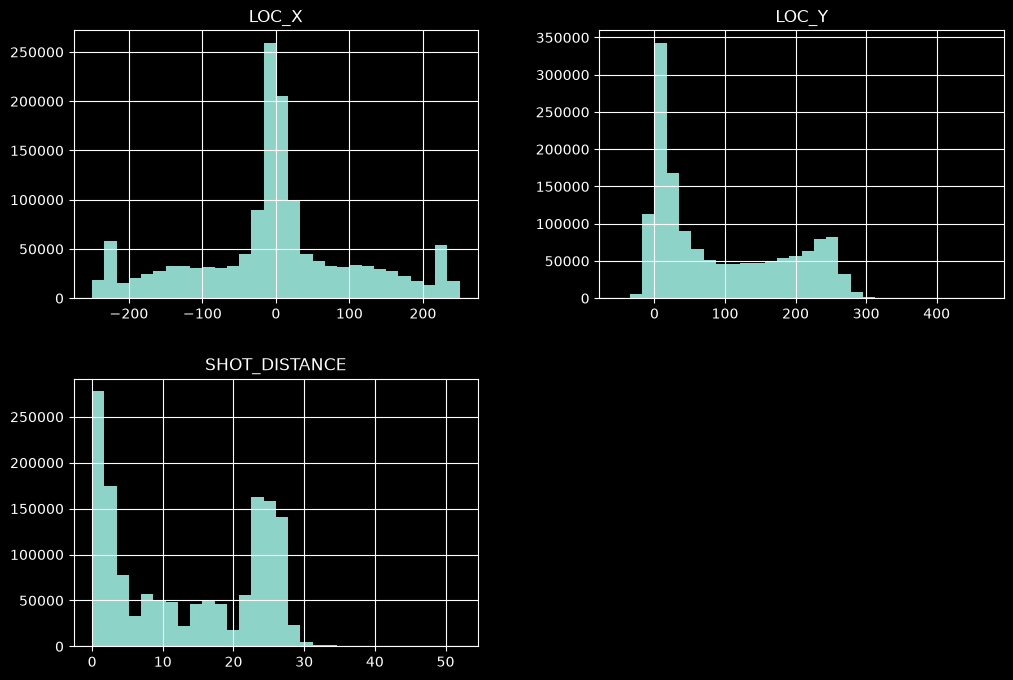

In [3]:
df[['LOC_X', 'LOC_Y', 'SHOT_DISTANCE']].hist(bins=30, figsize=(12, 8))


<Axes: xlabel='SHOT_CATEGORY'>

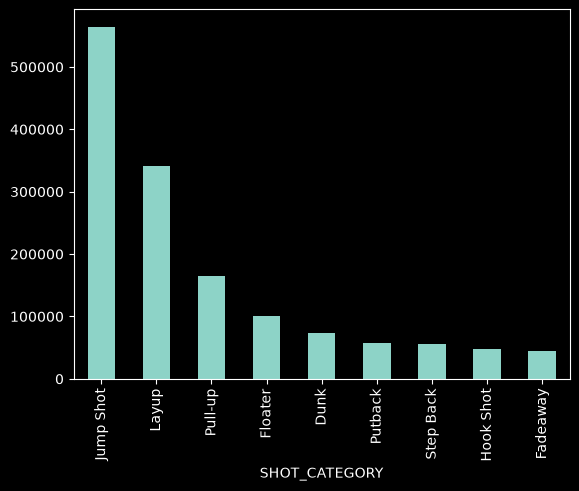

In [4]:
df['SHOT_CATEGORY'].value_counts().plot(kind='bar')


In [6]:
print(df.groupby('SHOT_CATEGORY')['SHOT_MADE_FLAG'].mean().sort_values())


df['DISTANCE_BUCKET'] = pd.cut(df['SHOT_DISTANCE'], bins=[0,5,10,15,20,25,30,35],)
print(df.groupby('DISTANCE_BUCKET', observed=False)['SHOT_MADE_FLAG'].mean())

SHOT_CATEGORY
Jump Shot    0.359192
Step Back    0.404420
Pull-up      0.419404
Fadeaway     0.430826
Floater      0.450148
Hook Shot    0.481187
Layup        0.556090
Putback      0.605816
Dunk         0.897112
Name: SHOT_MADE_FLAG, dtype: float64
DISTANCE_BUCKET
(0, 5]      0.558770
(5, 10]     0.416441
(10, 15]    0.423273
(15, 20]    0.408993
(20, 25]    0.370168
(25, 30]    0.345832
(30, 35]    0.259011
Name: SHOT_MADE_FLAG, dtype: float64


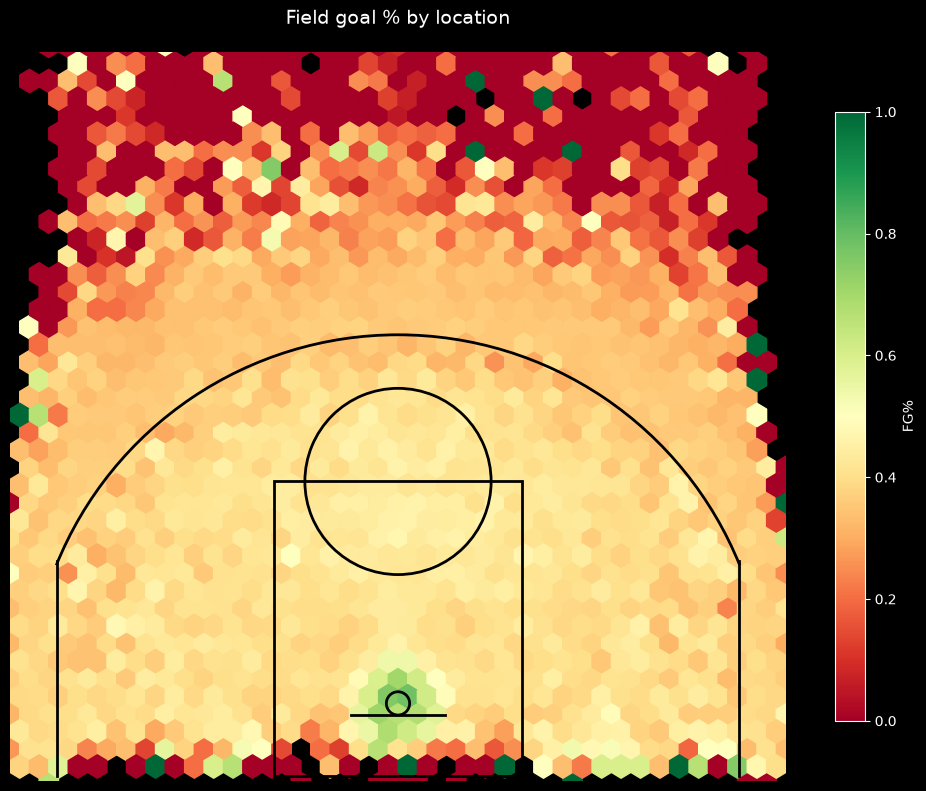

In [7]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

def draw_court(ax, color='white', lw=2):
    ax.add_patch(plt.Circle((0, 0), 7.5, fill=False, color=color, linewidth=lw))
    ax.plot([-30, 30], [-7.5, -7.5], color=color, linewidth=lw)
    ax.add_patch(patches.Rectangle((-80, -47), 160, 190, fill=False, color=color, linewidth=lw))
    ax.add_patch(patches.Arc((0, 143), 120, 120, theta1=0, theta2=360, color=color, linewidth=lw))
    ax.add_patch(patches.Arc((0, 0), 475, 475, theta1=22, theta2=158, color=color, linewidth=lw))
    ax.plot([-220, -220], [-47, 92], color=color, linewidth=lw)
    ax.plot([220, 220], [-47, 92], color=color, linewidth=lw)
    ax.set_xlim(-250, 250)
    ax.set_ylim(-50, 420)
    ax.set_aspect('equal')
    ax.axis('off')

fig, ax = plt.subplots(figsize=(10, 9))
ax.set_facecolor('#0d1117')

hb = ax.hexbin(df['LOC_X'], df['LOC_Y'],
               C=df['SHOT_MADE_FLAG'],
               reduce_C_function=np.mean,
               gridsize=40, cmap='RdYlGn',)

draw_court(ax, color='black', lw=2)
cb = plt.colorbar(hb, ax=ax, shrink=0.7)
cb.set_label('FG%', color='white')
plt.title('Field goal % by location', color='white', fontsize=14, pad=20)
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd


df = pd.read_parquet("../data/train_cleanData.parquet")
#analyzes the effect of the "moving" descriptor on shot fg%
piv = (df.groupby(['SHOT_CATEGORY', 'IS_MOVING'])['SHOT_MADE_FLAG']
         .agg(['mean', 'size']).unstack('IS_MOVING'))
piv.columns = ['fg_still', 'fg_moving', 'n_still', 'n_moving']
piv['delta'] = piv['fg_moving'] - piv['fg_still']
print(piv.round(3).sort_values('delta', ascending=False).to_string())

               fg_still  fg_moving   n_still  n_moving  delta
SHOT_CATEGORY                                                
Layup             0.514      0.692  259807.0   81467.0  0.178
Dunk              0.862      0.938   39215.0   34098.0  0.076
Jump Shot         0.357      0.423  548985.0   15259.0  0.066
Pull-up           0.419      0.422  156359.0    9233.0  0.003
Fadeaway          0.431        NaN   44728.0       NaN    NaN
Floater           0.450        NaN  100658.0       NaN    NaN
Hook Shot         0.481        NaN   48079.0       NaN    NaN
Putback           0.606        NaN   58044.0       NaN    NaN
Step Back         0.404        NaN   55932.0       NaN    NaN


In [11]:
js = df[df['SHOT_CATEGORY'] == 'Jump Shot']
print(js.groupby('IS_MOVING')['SHOT_DISTANCE'].agg(['mean', 'median', 'count']))
print(js.groupby('IS_MOVING')['SHOT_MADE_FLAG'].mean())
band = js[(js['SHOT_DISTANCE'] >= 18) & (js['SHOT_DISTANCE'] <= 24)]
print(band.groupby('IS_MOVING')['SHOT_MADE_FLAG'].agg(['mean', 'size']))

                mean  median   count
IS_MOVING                           
0          22.212250    24.0  548985
1          22.182122    24.0   15259
IS_MOVING
0    0.357412
1    0.423226
Name: SHOT_MADE_FLAG, dtype: float64
               mean    size
IS_MOVING                  
0          0.372910  209989
1          0.447976    5065


In [14]:
import pandas as pd

df = pd.read_parquet("../data/train_playerMode.parquet")
counts = df.groupby(['PLAYER_ID', 'SHOT_ZONE_BASIC']).size().unstack('SHOT_ZONE_BASIC').fillna(0)

five = ['Restricted Area', 'In The Paint (Non-RA)', 'Mid-Range', 'Above the Break 3', 'Corner 3']
qualified = counts[(counts[five] >= 200).all(axis=1)] #keep players with at least 200 shots from all shot zones
print(f"{len(qualified)} players qualify with merged corner")
print(qualified.index.tolist())

151 players qualify with merged corner
[2544, 2546, 101108, 101150, 200752, 200765, 200768, 201143, 201144, 201145, 201152, 201163, 201566, 201567, 201568, 201571, 201572, 201584, 201587, 201588, 201609, 201933, 201935, 201937, 201939, 201942, 201949, 201950, 201980, 202066, 202083, 202330, 202331, 202339, 202340, 202681, 202691, 202692, 202693, 202694, 202695, 202699, 202704, 202709, 202710, 202711, 202734, 203078, 203082, 203084, 203087, 203095, 203107, 203114, 203115, 203118, 203145, 203200, 203210, 203468, 203471, 203482, 203484, 203490, 203493, 203496, 203501, 203506, 203552, 203897, 203903, 203914, 203915, 203918, 203922, 203924, 203925, 203926, 203932, 203933, 203935, 203937, 203944, 203952, 203967, 203992, 204020, 204038, 1626145, 1626156, 1626157, 1626159, 1626162, 1626164, 1626168, 1626169, 1626171, 1626179, 1626181, 1626196, 1626224, 1627736, 1627741, 1627742, 1627747, 1627749, 1627750, 1627752, 1627759, 1627763, 1627783, 1627814, 1627832, 1627854, 1628366, 1628367, 1628368,

In [26]:
five = ['Restricted Area', 'In The Paint (Non-RA)', 'Mid-Range', 'Above the Break 3', 'Corner 3']

total = counts.sum(axis=1).sort_values(ascending=False)

# which zone is the one dragging a player below 200
def limiting(row):
    below = [z for z in five if row[z] < 200]
    return ', '.join(below) if below else 'QUALIFIES'

report = pd.DataFrame({
    'total_shots': total,
    'status': counts.loc[total.index].apply(limiting, axis=1),
})

print("=== TOP 60 BY VOLUME — qualification status ===")
print(report.head(60).to_string())

print("\n=== notable names that fail only ONE zone ===")
missed = report[report['status'] != 'QUALIFIES']
one_zone = missed[~missed['status'].str.contains(',')]
print(one_zone.head(30).to_string())

=== TOP 60 BY VOLUME — qualification status ===
           total_shots     status
PLAYER_ID                        
201942         11720.0  QUALIFIES
1626164        11508.0  QUALIFIES
203507         11446.0   Corner 3
201566         11334.0  QUALIFIES
2544           11118.0  QUALIFIES
203081         11117.0  QUALIFIES
201935         11079.0  QUALIFIES
203468         10985.0  QUALIFIES
203999         10492.0   Corner 3
1628378        10485.0  QUALIFIES
1628369        10423.0  QUALIFIES
202696         10200.0   Corner 3
203078         10169.0  QUALIFIES
201939         10083.0  QUALIFIES
203076          9563.0   Corner 3
203944          9541.0  QUALIFIES
202331          9456.0  QUALIFIES
203952          9278.0  QUALIFIES
1629029         9278.0   Corner 3
1626157         9264.0  QUALIFIES
202699          9250.0  QUALIFIES
202681          9136.0  QUALIFIES
1627759         8978.0  QUALIFIES
1627741         8976.0  QUALIFIES
1628368         8951.0  QUALIFIES
1629027         8921.0   Corner 3


In [27]:
import pandas as pd

df = pd.read_parquet("../data/train_playerMode.parquet")

counts = df.groupby(['PLAYER_ID', 'SHOT_ZONE_BASIC']).size().unstack('SHOT_ZONE_BASIC').fillna(0)
names  = df.groupby('PLAYER_ID')['PLAYER_NAME'].first()

five = ['Restricted Area', 'In The Paint (Non-RA)', 'Mid-Range', 'Above the Break 3', 'Corner 3']
c = counts[five]
total = c.sum(axis=1)

rule_400 = ((c >= 400).sum(axis=1) >= 2) #keep players with at least 400 shots from 2 areas
rule_200 = ((c >= 200).sum(axis=1) >= 4) #keep players with at least 200 shots from 4 areas

only_400 = total[rule_400 & ~rule_200].sort_values(ascending=False)  # 400/2 keeps, 200/4 drops
only_200 = total[rule_200 & ~rule_400].sort_values(ascending=False)  # 200/4 keeps, 400/2 drops
both     = total[rule_400 | rule_200].shape[0]                       # kept by either rule
lost     = total[~rule_400 & ~rule_200].sort_values(ascending=False) # neither keeps

print(f"rule ≥400/2 keeps {rule_400.sum()} | rule ≥200/4 keeps {rule_200.sum()} "
      f"| either keeps {both}\n")

def dump(series, header):
    print(f"=== {header}: {len(series)} players ===")
    for pid in series.index:
        z200 = int((c.loc[pid] >= 200).sum())
        z400 = int((c.loc[pid] >= 400).sum())
        print(f"{names[pid]:28s} total={int(total[pid]):6d}  ≥200:{z200}  ≥400:{z400}")
    print()

dump(only_400, "ONLY ≥400/2 keeps these players")
dump(only_200, "ONLY ≥200/4 keeps these players")

rule ≥400/2 keeps 301 | rule ≥200/4 keeps 259 | either keeps 328

=== ONLY ≥400/2 keeps these players: 69 players ===
Andre Drummond               total=  4887  ≥200:3  ≥400:2
Bam Adebayo                  total=  4249  ≥200:3  ≥400:3
Clint Capela                 total=  4192  ≥200:2  ≥400:2
Rudy Gobert                  total=  3963  ≥200:2  ≥400:2
Montrezl Harrell             total=  3946  ≥200:3  ≥400:2
Deandre Ayton                total=  3709  ≥200:3  ≥400:3
Steven Adams                 total=  3599  ≥200:2  ≥400:2
Hassan Whiteside             total=  3487  ≥200:3  ≥400:3
Ben Simmons                  total=  3413  ≥200:3  ≥400:2
Enes Freedom                 total=  3137  ≥200:3  ≥400:2
Jarrett Allen                total=  3082  ≥200:2  ≥400:2
T.J. McConnell               total=  2970  ≥200:3  ≥400:3
Robin Lopez                  total=  2952  ≥200:3  ≥400:3
Mason Plumlee                total=  2896  ≥200:2  ≥400:2
Trevor Ariza                 total=  2842  ≥200:3  ≥400:3
Jakob Poeltl

In [28]:
import json
from pathlib import Path
import pandas as pd

df = pd.read_parquet("../data/trainval_playerMode.parquet")

counts = df.groupby(['PLAYER_ID', 'SHOT_ZONE_BASIC']).size().unstack('SHOT_ZONE_BASIC').fillna(0)
names  = df.groupby('PLAYER_ID')['PLAYER_NAME'].first()

five = ['Restricted Area', 'In The Paint (Non-RA)', 'Mid-Range', 'Above the Break 3', 'Corner 3']
c = counts[five]
total = c.sum(axis=1)

rule = ((c >= 400).sum(axis=1) >= 2) #400/2 rule decided as a filter
roster = total[rule].sort_values(ascending=False)


id_to_cat = {pid: i + 1 for i, pid in enumerate(counts.index[rule])}

print(f"=== FINAL ROSTER: {rule.sum()} players (rule: ≥400 in ≥2 zones) ===\n")

ZONE_ABBR = {
    'Restricted Area': 'RA', 'In The Paint (Non-RA)': 'Paint',
    'Mid-Range': 'Mid', 'Above the Break 3': 'ATB3', 'Corner 3': 'C3',
}

selectable = {}
for pid in roster.index:
    row = c.loc[pid]
    sel_200 = [z for z in five if row[z] >= 200]
    sel_400 = [z for z in five if row[z] >= 400]
    selectable[str(id_to_cat[pid])] = {"name": names[pid], "zones": sel_200}

    abbr_200 = ' '.join(ZONE_ABBR[z] for z in sel_200)
    abbr_400 = ' '.join(ZONE_ABBR[z] for z in sel_400)
    print(f"{names[pid]:26s} total={int(total[pid]):6d} | ≥400: {abbr_400:22s} | ≥200: {abbr_200}")

Path("../shared/player_zones.preview.json").write_text(json.dumps(selectable, indent=2))

=== FINAL ROSTER: 362 players (rule: ≥400 in ≥2 zones) ===

DeMar DeRozan              total= 11720 | ≥400: RA Paint Mid ATB3 C3   | ≥200: RA Paint Mid ATB3 C3
Devin Booker               total= 11508 | ≥400: RA Paint Mid ATB3 C3   | ≥200: RA Paint Mid ATB3 C3
Giannis Antetokounmpo      total= 11446 | ≥400: RA Paint Mid ATB3      | ≥200: RA Paint Mid ATB3
Russell Westbrook          total= 11334 | ≥400: RA Paint Mid ATB3 C3   | ≥200: RA Paint Mid ATB3 C3
LeBron James               total= 11118 | ≥400: RA Paint Mid ATB3      | ≥200: RA Paint Mid ATB3 C3
Damian Lillard             total= 11117 | ≥400: RA Paint Mid ATB3      | ≥200: RA Paint Mid ATB3 C3
James Harden               total= 11079 | ≥400: RA Paint Mid ATB3      | ≥200: RA Paint Mid ATB3 C3
CJ McCollum                total= 10985 | ≥400: RA Paint Mid ATB3 C3   | ≥200: RA Paint Mid ATB3 C3
Nikola Jokić               total= 10492 | ≥400: RA Paint Mid ATB3      | ≥200: RA Paint Mid ATB3
Donovan Mitchell           total= 10485 | ≥400

61329

In [29]:
import pandas as pd
#data checkup
train = pd.read_parquet("../data/train_playerMode.parquet")
val   = pd.read_parquet("../data/val_playerMode.parquet")
test  = pd.read_parquet("../data/test_playerMode.parquet")

print(train['SHOT_ZONE_BASIC'].value_counts())
# should show 5 zones, 'Corner 3' merged, no 'Backcourt'

tr_ids, va_ids, te_ids = set(train.PLAYER_ID), set(val.PLAYER_ID), set(test.PLAYER_ID)
print("\nval IDs not in train:", va_ids - tr_ids)   # -1
print("test IDs not in train:", te_ids - tr_ids)     # -1

# other bucket stats
print("\n-1 present:", -1 in tr_ids)
print("OTHER share:", round((train.PLAYER_ID == -1).mean(), 3))
print("roster size (excl OTHER):", train.PLAYER_ID.nunique() - 1)

# 4. Nan checkup
print("\nnulls:\n", train.isnull().sum())
print("LOC_Y max:", train.LOC_Y.max())   # must be < 470

curry = train[train.PLAYER_NAME == 'Stephen Curry']
print(curry.groupby('SHOT_ZONE_BASIC').size())
print("Curry's ID bucketed?", curry.PLAYER_ID.unique())
print(train.head(50))

SHOT_ZONE_BASIC
Restricted Area          452504
Above the Break 3        404887
In The Paint (Non-RA)    244896
Mid-Range                223283
Corner 3                 125516
Name: count, dtype: int64

val IDs not in train: {1631232, 1641989, 1642502, 1642505, 1631241, 1631243, 1642269, 1641998, 1631247, 1631248, 1642270, 1631250, 1631255, 1631257, 1642013, 1631262, 1642273, 1642530, 1642024, 1642275, 1630762, 1629232, 1630259, 1642277, 1642278, 1642050, 1631301, 1642281, 1630283, 1631321, 1630811, 1630311, 1631338, 1631342, 1631376, 1631386, 1630929, 203995, 1641705, 1641706, 1641707, 1641708, 1641709, 1641710, 1641711, 1641712, 1641713, 1641715, 1641716, 1641717, 1641718, 1641720, 1641721, 1641722, 1641723, 1641724, 1641725, 1641726, 1641727, 1641729, 1641730, 1641731, 1641732, 1641733, 1641734, 1641735, 1641736, 1641737, 1628426, 1641738, 1641739, 1641740, 1641741, 1641744, 1641745, 1642258, 1642259, 1641748, 1641749, 1642261, 1642262, 1641752, 1641753, 1641754, 1641755, 1642263, 1

In [20]:
import pandas as pd

df = pd.read_parquet('../data/train_cleanData.parquet')
c3 = df[df['SHOT_ZONE_BASIC'].isin(['Left Corner 3', 'Right Corner 3'])]

#prints loc quantiles so reasonable zone borders are drawn
print(c3['LOC_Y'].describe())
print(c3['LOC_Y'].quantile([.01, .05, .1, .25, .5, .75, .9, .99]))

print(c3['LOC_X'].describe())
print(c3['LOC_X'].quantile([.01, .05, .1, .25, .5, .75, .9, .99]))

count    125516.000000
mean         21.624104
std          26.326542
min         -48.000000
25%           2.000000
50%          17.000000
75%          38.000000
max          87.000000
Name: LOC_Y, dtype: float64
0.01   -26.0
0.05   -16.0
0.10   -10.0
0.25     2.0
0.50    17.0
0.75    38.0
0.90    62.0
0.99    84.0
Name: LOC_Y, dtype: float64
count    125516.000000
mean         -9.335113
std         230.594465
min        -250.000000
25%        -231.000000
50%        -222.000000
75%         230.000000
max         250.000000
Name: LOC_X, dtype: float64
0.01   -242.0
0.05   -237.0
0.10   -235.0
0.25   -231.0
0.50   -222.0
0.75    230.0
0.90    235.0
0.99    242.0
Name: LOC_X, dtype: float64
